# Libraries

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("../data/raw/order_return_data.csv")

# Overview

In [6]:
print(df.shape)
print(df.head())
print(df.info())
print(df.describe())

(100000, 14)
   order_item_id  order_date delivery_date  item_id item_size item_color  \
0              1  2016-06-22    2016-06-27      643        38       navy   
1              2  2016-06-22           NaN      337       152       grey   
2              3  2016-06-22    2016-06-27      270       xxl       grey   
3              4  2016-06-22    2016-06-27      142       xxl       grey   
4              5  2016-06-22    2016-06-27      561       xxl       grey   

   brand_id  item_price  user_id user_title    user_dob          user_state  \
0        30       49.90    30822        Mrs  1969-04-17              Saxony   
1        30       19.95    30822        Mrs  1969-04-17              Saxony   
2        49       79.90    30823        Mrs  1970-04-22  Baden-Wuerttemberg   
3        49       99.90    30823        Mrs  1970-04-22  Baden-Wuerttemberg   
4         3       14.90    30823        Mrs  1970-04-22  Baden-Wuerttemberg   

  user_reg_date  return  
0    2016-06-23       0  
1  

# Bo'sh qiymatlar

order_item_id       0
order_date          0
delivery_date    9318
item_id             0
item_size           0
item_color          0
brand_id            0
item_price          0
user_id             0
user_title          0
user_dob         8725
user_state          0
user_reg_date       0
return              0
dtype: int64


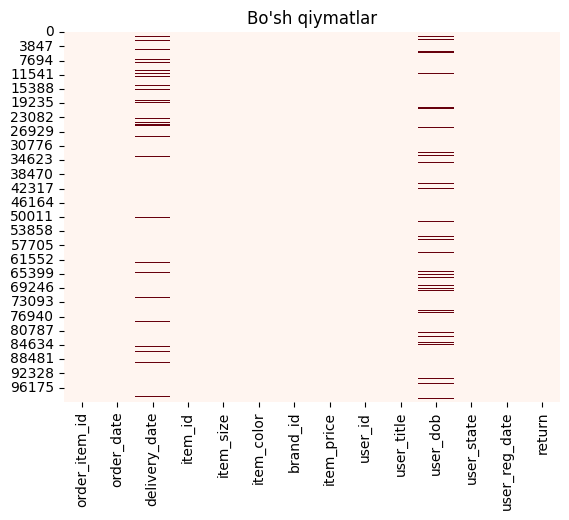

In [7]:
print(df.isnull().sum())
sns.heatmap(df.isnull(), cbar=False, cmap="Reds")
plt.title("Bo'sh qiymatlar")
plt.show()

# Target distribution (return: 0 and 1)


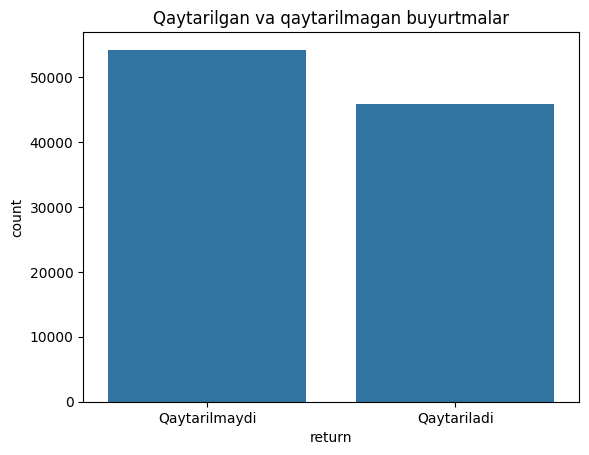

return
0    0.54182
1    0.45818
Name: proportion, dtype: float64


In [8]:
sns.countplot(x="return", data=df)
plt.title("Qaytarilgan va qaytarilmagan buyurtmalar")
plt.xticks([0, 1], ["Qaytarilmaydi", "Qaytariladi"])
plt.show()
print(df["return"].value_counts(normalize=True))

# Price distribution

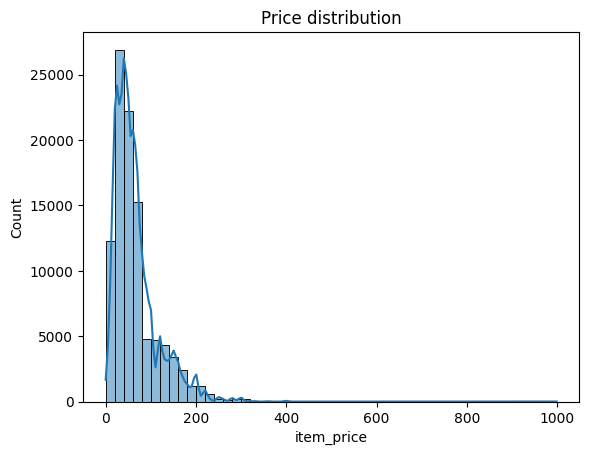

In [10]:
sns.histplot(df["item_price"], bins=50, kde=True)
plt.title("Price distribution")
plt.show()

# Item size va return bog'liqligi

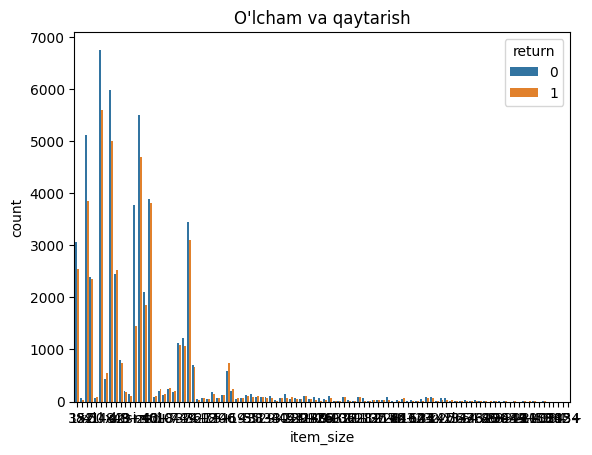

In [11]:
sns.countplot(x="item_size", hue="return", data=df)
plt.title("O'lcham va qaytarish")
plt.show()

# Item color va return

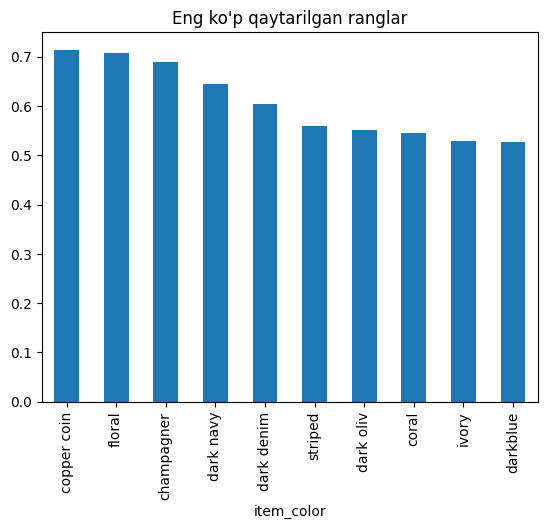

In [12]:
df.groupby("item_color")["return"].mean().sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Eng ko'p qaytarilgan ranglar")
plt.show()

# User state va return

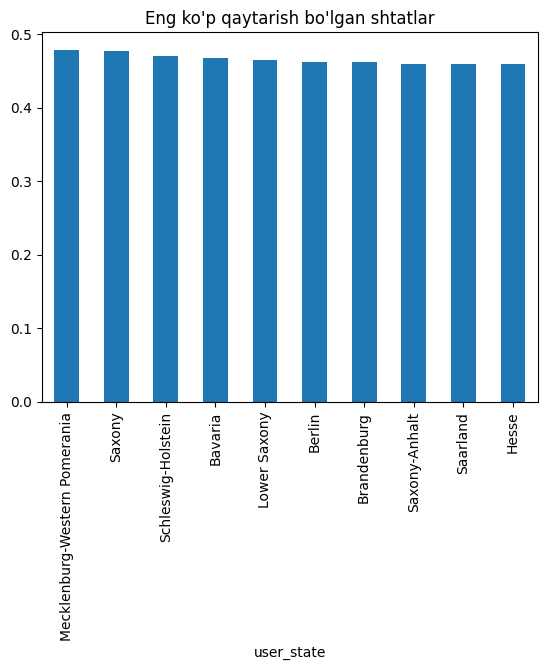

In [13]:
df.groupby("user_state")["return"].mean().sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Eng ko'p qaytarish bo'lgan shtatlar")
plt.show()

# Price and return

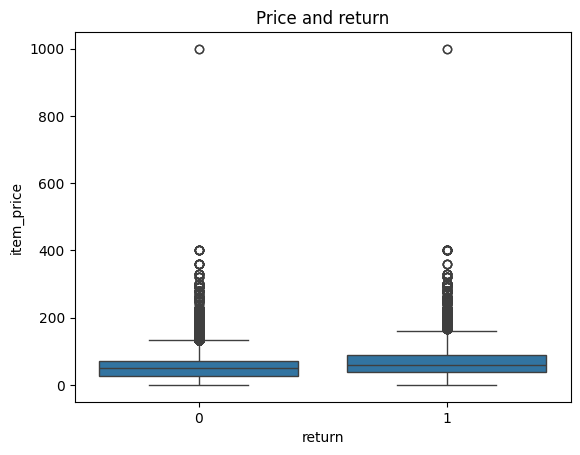

In [17]:
sns.boxplot(x="return", y="item_price", data=df)
plt.title("Price and return")
plt.show()

# Correlation

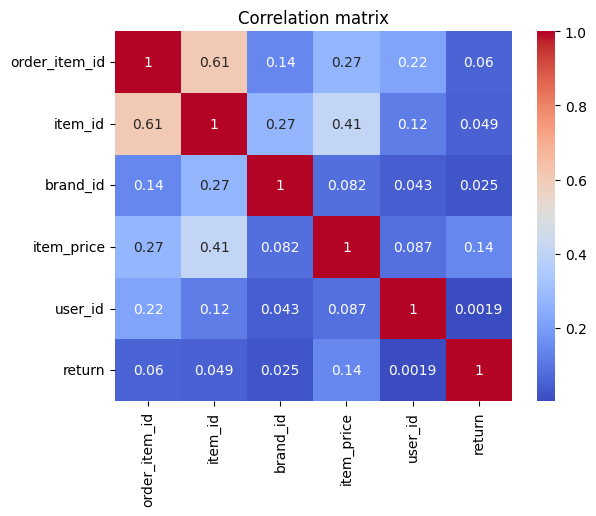

In [16]:
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")
plt.title("Correlation matrix")
plt.show()